In [3]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

### verify the neutron source

Positions r:
 [[-0.00155  0.00982  0.     ]
 [ 0.00654 -0.01063  0.     ]
 [ 0.0186  -0.0003   0.     ]
 [-0.00628 -0.01815  0.     ]
 [-0.01402 -0.00084  0.     ]
 [ 0.01289 -0.00867  0.     ]
 [ 0.00797  0.00909  0.     ]
 [ 0.00128  0.01617  0.     ]
 [-0.01536 -0.00176  0.     ]
 [-0.01186 -0.00109  0.     ]
 [-0.01028  0.01305  0.     ]
 [-0.01173  0.01112  0.     ]
 [-0.00479  0.0167   0.     ]
 [-0.00761 -0.01458  0.     ]
 [ 0.00019  0.01037  0.     ]
 [ 0.00838 -0.00884  0.     ]
 [ 0.00129  0.00677  0.     ]
 [-0.00465  0.01101  0.     ]
 [ 0.00238 -0.00717  0.     ]
 [-0.0015   0.00646  0.     ]
 [-0.00411 -0.00275  0.     ]
 [ 0.01336 -0.00787  0.     ]
 [-0.01286  0.00496  0.     ]
 [ 0.01401  0.01129  0.     ]
 [ 0.00034  0.00373  0.     ]
 [-0.01674  0.00188  0.     ]
 [-0.01477 -0.01135  0.     ]
 [ 0.00235  0.01894  0.     ]
 [-0.00235  0.0053   0.     ]
 [-0.00161  0.00324  0.     ]]

Directions vec:
 [[ 3.1490e-02 -5.0430e-02  9.9823e-01]
 [ 7.2110e-02  3.6790e-02  9

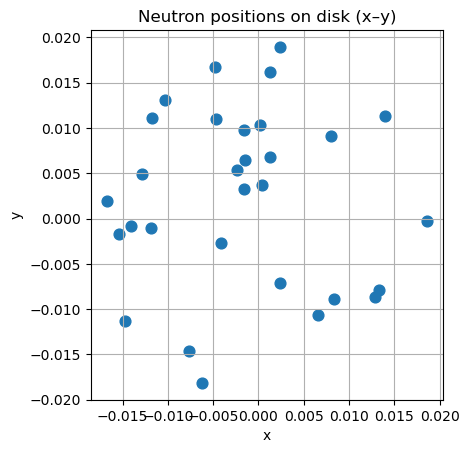

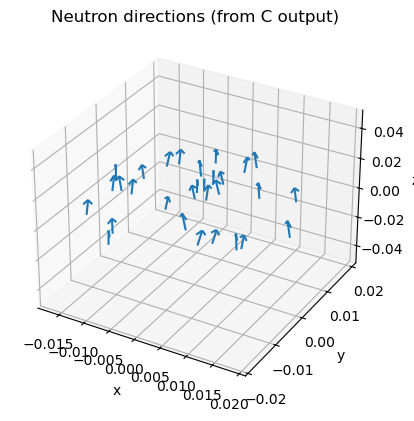

Direction norms: [0.99999897 1.00000206 0.99999781 0.99999733 0.99999946 1.00000119
 1.00000274 0.99999874 1.00000173 0.99999576 0.99999584 0.99999583
 0.99999953 0.99999781 1.00000404 0.99999795 0.99999998 1.00000395
 0.99999649 0.99999805 1.00000065 0.99999615 0.9999951  1.00000358
 0.99999786 0.99999627 1.00000376 1.00000004 0.99999733 1.00000128]


In [4]:
# ---- Raw data copied from C output ----
raw = """
r = (-0.00155 0.00982 0.00000)
vec = (0.03149 -0.05043 0.99823)
r = (0.00654 -0.01063 0.00000)
vec = (0.07211 0.03679 0.99672)
r = (0.01860 -0.00030 0.00000)
vec = (-0.06901 0.03263 0.99708)
r = (-0.00628 -0.01815 0.00000)
vec = (0.02453 -0.02475 0.99939)
r = (-0.01402 -0.00084 0.00000)
vec = (-0.03100 -0.02444 0.99922)
r = (0.01289 -0.00867 0.00000)
vec = (-0.03374 0.03824 0.99870)
r = (0.00797 0.00909 0.00000)
vec = (-0.04061 0.02598 0.99884)
r = (0.00128 0.01617 0.00000)
vec = (0.02194 0.07421 0.99700)
r = (-0.01536 -0.00176 0.00000)
vec = (0.01664 0.04717 0.99875)
r = (-0.01186 -0.00109 0.00000)
vec = (0.02180 0.02993 0.99931)
r = (-0.01028 0.01305 0.00000)
vec = (0.02704 0.02098 0.99941)
r = (-0.01173 0.01112 0.00000)
vec = (0.05412 0.03658 0.99786)
r = (-0.00479 0.01670 0.00000)
vec = (0.01297 -0.00713 0.99989)
r = (-0.00761 -0.01458 0.00000)
vec = (-0.00352 -0.00482 0.99998)
r = (0.00019 0.01037 0.00000)
vec = (-0.02258 -0.07738 0.99675)
r = (0.00838 -0.00884 0.00000)
vec = (0.08102 -0.00091 0.99671)
r = (0.00129 0.00677 0.00000)
vec = (-0.05058 -0.03921 0.99795)
r = (-0.00465 0.01101 0.00000)
vec = (-0.05623 0.04219 0.99753)
r = (0.00238 -0.00717 0.00000)
vec = (-0.08148 0.02326 0.99640)
r = (-0.00150 0.00646 0.00000)
vec = (0.03502 -0.06943 0.99697)
r = (-0.00411 -0.00275 0.00000)
vec = (0.07777 -0.03347 0.99641)
r = (0.01336 -0.00787 0.00000)
vec = (0.05500 -0.01564 0.99836)
r = (-0.01286 0.00496 0.00000)
vec = (-0.01876 -0.03518 0.99920)
r = (0.01401 0.01129 0.00000)
vec = (-0.02361 -0.03534 0.99910)
r = (0.00034 0.00373 0.00000)
vec = (0.02255 0.04273 0.99883)
r = (-0.01674 0.00188 0.00000)
vec = (-0.03492 0.04909 0.99818)
r = (-0.01477 -0.01135 0.00000)
vec = (0.03001 0.01966 0.99936)
r = (0.00235 0.01894 0.00000)
vec = (-0.06855 0.02955 0.99721)
r = (-0.00235 0.00530 0.00000)
vec = (0.03262 -0.03986 0.99867)
r = (-0.00161 0.00324 0.00000)
vec = (-0.02240 -0.06719 0.99749)
"""

# ---- Parse ----
lines = [l.strip() for l in raw.splitlines() if l.strip()]

r_list = []
v_list = []

for i in range(0, len(lines), 2):
    r_vals = lines[i].split("(")[1].split(")")[0].split()
    v_vals = lines[i+1].split("(")[1].split(")")[0].split()
    r_list.append([float(x) for x in r_vals])
    v_list.append([float(x) for x in v_vals])

r = np.array(r_list)
v = np.array(v_list)

print("Positions r:\n", r)
print("\nDirections vec:\n", v)


plt.figure()
plt.scatter(r[:,0], r[:,1], s=60)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neutron positions on disk (x–y)")
plt.grid(True)
plt.show()

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.quiver(
    r[:,0], r[:,1], r[:,2],
    v[:,0], v[:,1], v[:,2],
    length=0.01,
    normalize=True
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Neutron directions (from C output)")
plt.show()

norms = np.linalg.norm(v, axis=1)
print("Direction norms:", norms)




### Monitor verification. plotting of the detection of only beam on monitor

Hit positions:
 [[-0.06110289 -0.00243215  0.99812851]
 [ 0.01005675 -0.00509985  0.99993642]
 [ 0.06454129  0.06973908  0.9954752 ]
 ...
 [-0.02980073  0.00424605  0.99954684]
 [-0.05723186 -0.03995901  0.99756092]
 [-0.0367704   0.02620191  0.99898018]]


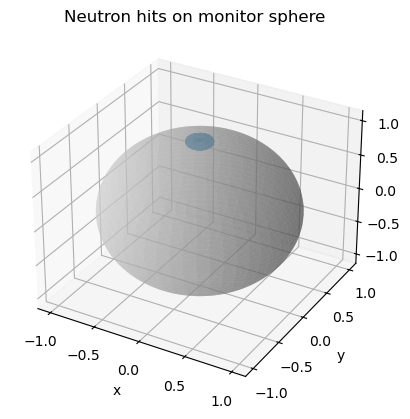

In [5]:
# import csv file with hit coordinates
sphere_hits_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/sphere_hits.csv")
if not sphere_hits_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {sphere_hits_path}")

with sphere_hits_path.open(newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    hits = [row for row in reader]

hit_positions = np.array([[float(hit['hit_x']), float(hit['hit_y']), float(hit['hit_z'])] for hit in hits])
print("Hit positions:\n", hit_positions)


# Plot hit positions on the sphere
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(hit_positions[:,0], hit_positions[:,1], hit_positions[:,2], s=20)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Neutron hits on monitor sphere")
# add shadow of the sphere for reference
R = 1.0
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = R * np.outer(np.cos(u), np.sin(v))
y = R * np.outer(np.sin(u), np.sin(v))
z = R * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='lightgray', alpha=0.5)
plt.show()
    

### plot and check the hits on a flat plane in front of beam source

Hit positions:
 [[ 0.052362 -0.007334  1.5     ]
 [ 0.118641  0.100694  1.5     ]
 [-0.120087 -0.154249  1.5     ]
 ...
 [ 0.037846 -0.131111  1.5     ]
 [-0.117581  0.071607  1.5     ]
 [-0.151364  0.161014  1.5     ]]


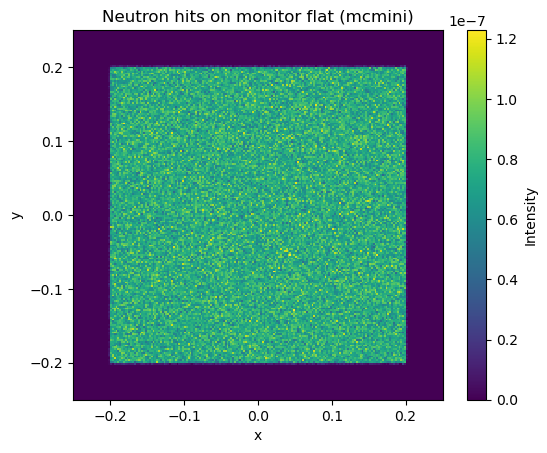

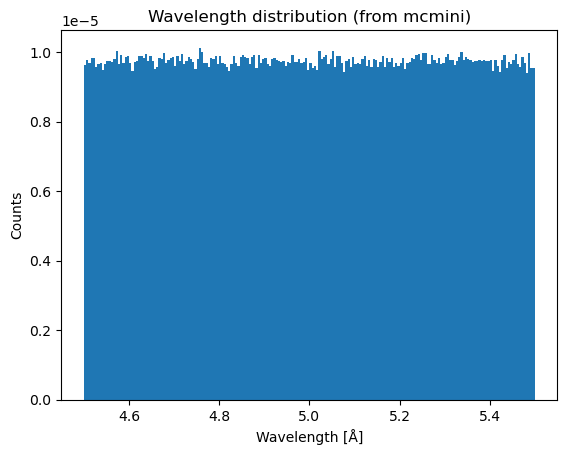

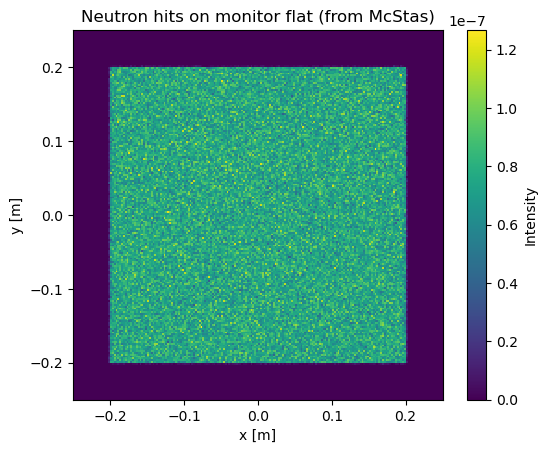

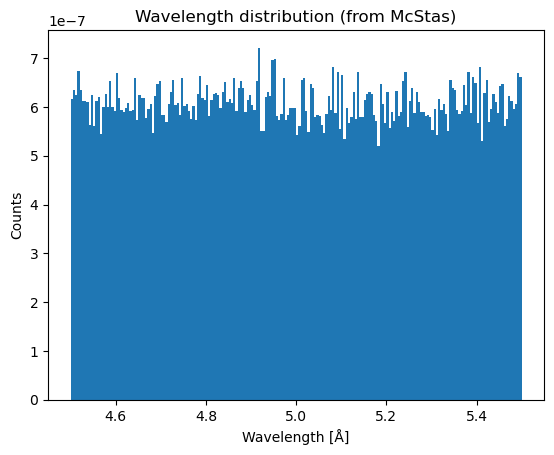

In [6]:
# import csv file with hit coordinates
sphere_hits_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits.csv")
if not sphere_hits_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {sphere_hits_path}")

with sphere_hits_path.open(newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    hits = [row for row in reader]

hit_positions = np.array([[float(hit['hit_x']), float(hit['hit_y']), float(hit['hit_z'])] for hit in hits])
lambda_values = np.array([float(hit['lambda']) for hit in hits])
print("Hit positions:\n", hit_positions)

# bin the hit positions for a 2D histogram
x_edges = np.linspace(-0.25, 0.25, 201)
y_edges = np.linspace(-0.25, 0.25, 201)
hist, x_edges, y_edges = np.histogram2d(hit_positions[:,0], hit_positions[:,1], bins=[x_edges, y_edges])
lambda_edges = np.linspace(4.5, 5.5, 201)  # example lambda bins
hist = hist/np.sum(hist) * 0.00194955  # normalize to total counts

# plot the 2D histogram
plt.figure()
plt.imshow(hist.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Intensity')
# zoom out to see the full monitor area
plt.xlim(-0.25, 0.25)
plt.ylim(-0.25, 0.25)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neutron hits on monitor flat (mcmini)")
plt.show()

# plot lambda data from mcmini
hist_lambda, lambda_edges = np.histogram(lambda_values, bins=lambda_edges)
hist_lambda = hist_lambda / np.sum(hist_lambda) * 0.00194955  # normalize to total counts
plt.figure()
bin_centers = (lambda_edges[:-1] + lambda_edges[1:]) / 2
plt.bar(bin_centers, hist_lambda, width=(lambda_edges[1] - lambda_edges[0]), align='center')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Counts")
plt.title("Wavelength distribution (from mcmini)")
plt.show()


# plot the data from mcstas
mcstas_folder = "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/test_0p5m_mon"
flat_plane_hits = ms.load_data(mcstas_folder)[-1]  # adjust index if needed
meta = flat_plane_hits.metadata




# extract intensity profiles (adjust index/name as needed)
hits = flat_plane_hits.Intensity
# find the limits of the monitor from metadata
(xmin, xmax, ymin, ymax) = meta.limits
xmin /= 100; xmax /= 100
ymin /= 100; ymax /= 100
H = flat_plane_hits.Intensity  # or .data depending on your object
extent = [xmin, xmax, ymin, ymax]
# plot the intensity profile on a heatmap
plt.imshow(H.T, origin="lower", extent=extent, interpolation="nearest")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.colorbar(label='Intensity')
plt.title("Neutron hits on monitor flat (from McStas)")
plt.show()

# lambda histogram 
mcstas_lambda_folder = "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/lambda_test"
lambda_mon = ms.load_data(mcstas_lambda_folder)[-1]  # adjust index if needed
lambda_data = lambda_mon.Intensity
meta = lambda_mon.metadata
xmin, xmax = meta.limits  # only one axis
# plot the lambda histogram
bin_centers = (np.arange(len(lambda_data)) + 0.5) * (xmax - xmin) / len(lambda_data) + xmin
plt.bar(bin_centers, lambda_data, width=(xmax - xmin) / len(lambda_data), align='center')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Counts")
plt.title("Wavelength distribution (from McStas)")
plt.show()




### plot and check the hits on a flat plane in front of beam source. now normalized to match intensity

Hit positions:
 [[ 0.052362 -0.007334  1.5     ]
 [ 0.118641  0.100694  1.5     ]
 [-0.120087 -0.154249  1.5     ]
 ...
 [ 0.037846 -0.131111  1.5     ]
 [-0.117581  0.071607  1.5     ]
 [-0.151364  0.161014  1.5     ]]
RMS difference (shape only) = 7.045104683411682e-06
RMS difference (absolute intensity) = 1.3734788262834872e-08
Relative RMS error = 0.3909492396796068
Chi^2 = 0.21493321644150254
Chi^2 / dof = 8.201679632202646e-06


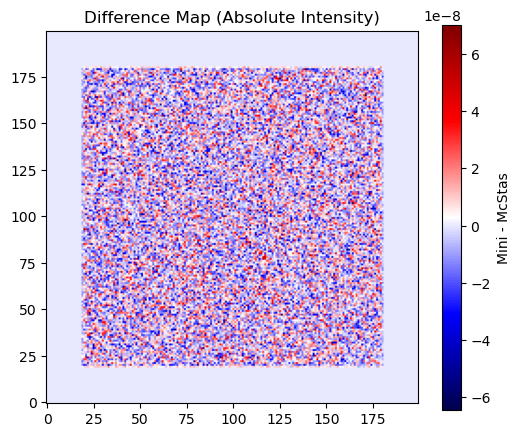

In [7]:
import numpy as np

# --- Inputs ---
# import csv file with hit coordinates
sphere_hits_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits.csv")
if not sphere_hits_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {sphere_hits_path}")

with sphere_hits_path.open(newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    hits = [row for row in reader]

hit_positions = np.array([[float(hit['hit_x']), float(hit['hit_y']), float(hit['hit_z'])] for hit in hits])
lambda_values = np.array([float(hit['lambda']) for hit in hits])
print("Hit positions:\n", hit_positions)

# bin the hit positions for a 2D histogram
x_edges = np.linspace(-0.25, 0.25, 201)
y_edges = np.linspace(-0.25, 0.25, 201)
hist, x_edges, y_edges = np.histogram2d(hit_positions[:,0], hit_positions[:,1], bins=[x_edges, y_edges])

# plot the data from mcstas
mcstas_folder = "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/test_0p5m_mon"
flat_plane_hits = ms.load_data(mcstas_folder)[-1]  # adjust index if needed
# extract intensity profiles (adjust index/name as needed)
H = flat_plane_hits.Intensity  # or .data depending on your object

hist_mcmini = hist  # from mcmini
hist_mcstas = H  # from McStas
H_mini_raw = hist_mcmini.copy()
H_mcstas_raw = hist_mcstas.copy()

Nsim = 1_000_000              # mcmini simulated histories
I_mcstas = 0.00194955         # monitor integral from McStas metadata

# shape comparison (normalize both to 1)
P_mini = H_mini_raw / np.sum(H_mini_raw)
P_mcstas = H_mcstas_raw / np.sum(H_mcstas_raw)

diff_shape = P_mini - P_mcstas
rms_shape = np.sqrt(np.mean(diff_shape**2))

print("RMS difference (shape only) =", rms_shape)

# absolute intensity comparison (scale mcmini to match McStas total)
H_mini_scaled = P_mini * I_mcstas

diff_abs = H_mini_scaled - H_mcstas_raw
rms_abs = np.sqrt(np.mean(diff_abs**2))

print("RMS difference (absolute intensity) =", rms_abs)

# relative error only where McStas has nonzero intensity
mask = H_mcstas_raw > 0
rel_error = diff_abs[mask] / H_mcstas_raw[mask]
rms_rel = np.sqrt(np.mean(rel_error**2))

print("Relative RMS error =", rms_rel)


# McStas intensity per bin ~ sum(weights)/N
# For Poisson: variance ~ counts/N^2
# We approximate variance using mcmini counts

counts_mini = H_mini_raw
variance = counts_mini / (Nsim**2)
variance[variance == 0] = np.inf  # avoid divide by zero

chi2 = np.sum((diff_abs**2) / variance)
ndof = np.sum(mask)

print("Chi^2 =", chi2)
print("Chi^2 / dof =", chi2 / ndof)


plt.figure(figsize=(6,5))
plt.imshow(diff_abs.T, origin='lower', cmap='seismic')
plt.colorbar(label="Mini - McStas")
plt.title("Difference Map (Absolute Intensity)")
plt.show()


### checking the binned monitor result from mcmini 17/2

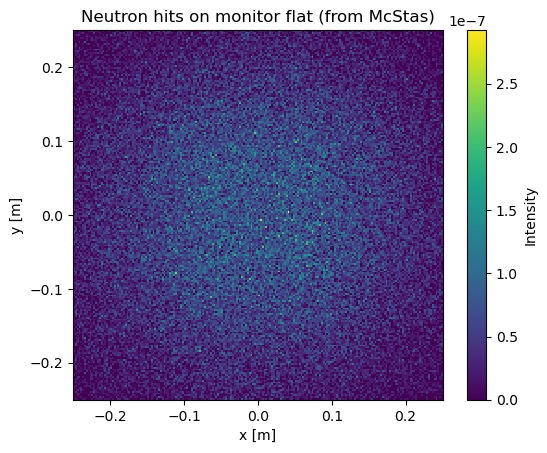

In [8]:
# plot binned data from mcmini 
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits_binned.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
# extract binned data
binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', skiprows=6)
x_edges = np.linspace(-0.25, 0.25, 201)
y_edges = np.linspace(-0.25, 0.25, 201)
col_x = binned_data[:,0]
col_y = binned_data[:,1]
col_counts = binned_data[:,2]
H = col_counts.reshape((200, 200)) * 0.00194955 # reshape to 2D histogram
extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

# plot the intensity profile on a heatmap
plt.imshow(H.T, origin="lower", extent=extent, interpolation="nearest")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.colorbar(label='Intensity')
plt.title("Neutron hits on monitor flat (from McStas)")
plt.show()

### 23/2. sphere monitor has now been binned as well. plot the result. no vanadium sample present, only the source

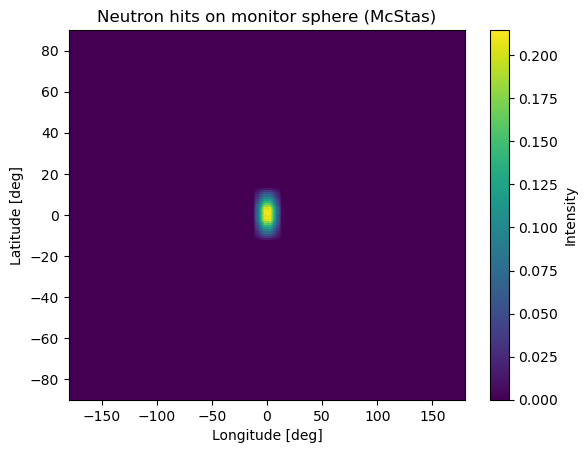

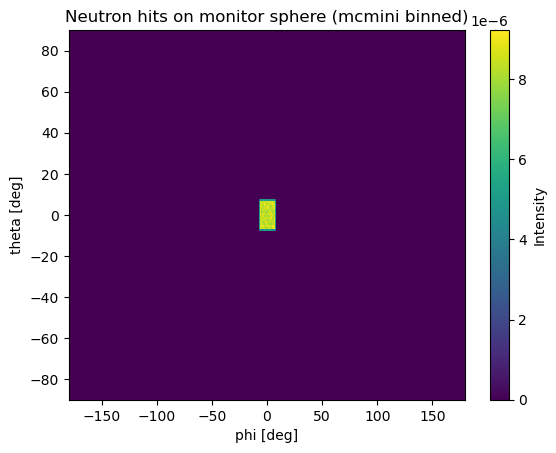

In [9]:
# first plot source to sphere monitor only from mcstas
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/sphere_mon")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity

xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]

# Decide orientation by comparing shapes
nx_meta, ny_meta = meta.dimension

Hmc = hits
if Hmc.shape == (nx_meta, ny_meta):
    # many McStas loaders store as (nx, ny) but imshow expects (ny, nx)
    Hmc = Hmc.T
elif Hmc.shape == (ny_meta, nx_meta):
    # already (ny, nx)
    pass
else:
    print("Unexpected hits shape:", Hmc.shape, "metadata:", meta.dimension)

plt.imshow(Hmc, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
plt.ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (McStas)")
plt.show()





# plot binned data from mcmini 
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/sphere_hits_binned.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
# extract binned data
nx, ny = 360, 180

binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
# (using comments='#' is safer than skiprows=6)

col_counts = binned_data[:,2]

H = col_counts.reshape((ny, nx)) # (180, 360) = (theta bins, phi bins)
H = col_counts.reshape((ny, nx)) * 0.00194955  # (360, 180) = (phi bins, theta bins)

extent = [-180, 180, -90, 90]
plt.imshow(H, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel("phi [deg]")
plt.ylabel("theta [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (mcmini binned)")
plt.show()


### creation of the source_simple and to better check if 4PI monitor matches in both mcstas and mcmini

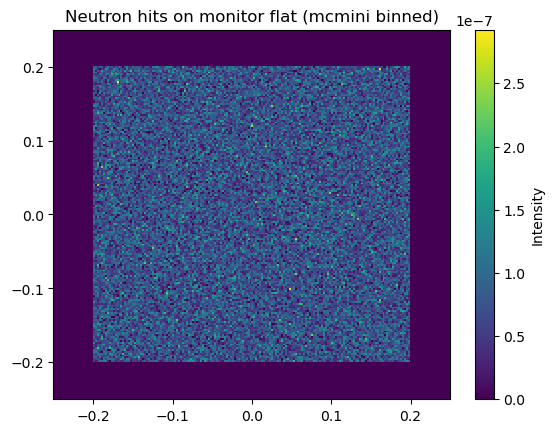

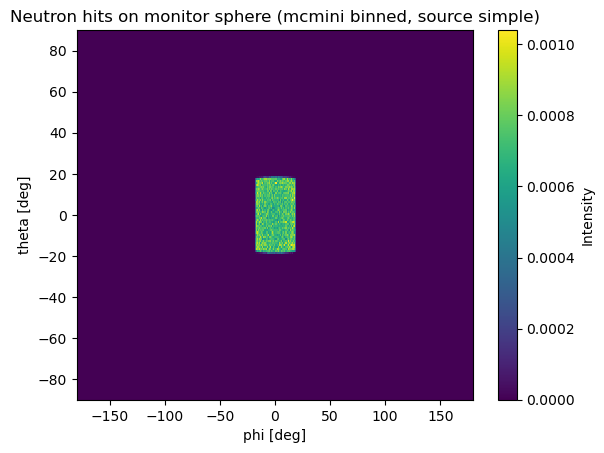

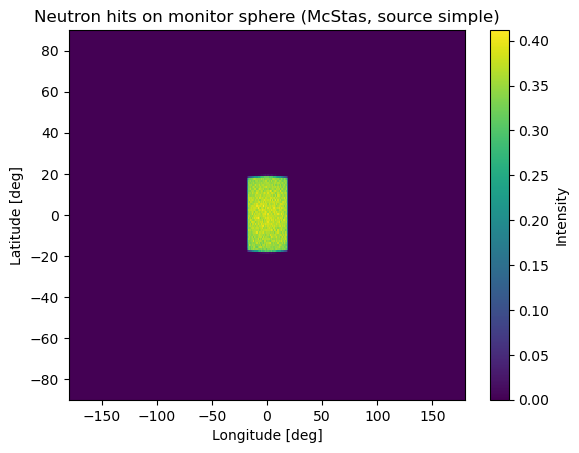

In [10]:
# plot binned data from mcmini 
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/flat_hits_binned_srcsimple.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
# extract binned data
nx, ny = 200, 200
x_edges = np.linspace(-0.25, 0.25, nx+1)
y_edges = np.linspace(-0.25, 0.25, ny+1)

binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
# (using comments='#' is safer than skiprows=6)

col_counts = binned_data[:,2]

H = col_counts.reshape((ny, nx)) # (180, 360) = (theta bins, phi bins)
H = col_counts.reshape((ny, nx)) * 0.00194955  # (360, 180) = (phi bins, theta bins)

extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]
plt.imshow(H, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor flat (mcmini binned)")
plt.show()



# data from sphere monitor (binned) and soruce simple
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/sphere_hits_binned_srcsimple.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
# extract binned data
nx, ny = 360, 180
binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
col_counts = binned_data[:,2]
H = col_counts.reshape((ny, nx)) # normalize to total counts
# H = col_counts.reshape((ny, nx)) * 85.8135 # for 0.4m focus
extent = [-180, 180, -90, 90]
plt.imshow(H, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel("phi [deg]")
plt.ylabel("theta [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (mcmini binned, source simple)")
plt.show()


# plot the data from mcstas
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/sphere_mon_srcsimple")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = hits
if Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
plt.imshow(Hmc, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
plt.ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (McStas, source simple)")
plt.show()

### the solid sphere multiple scatter plotting

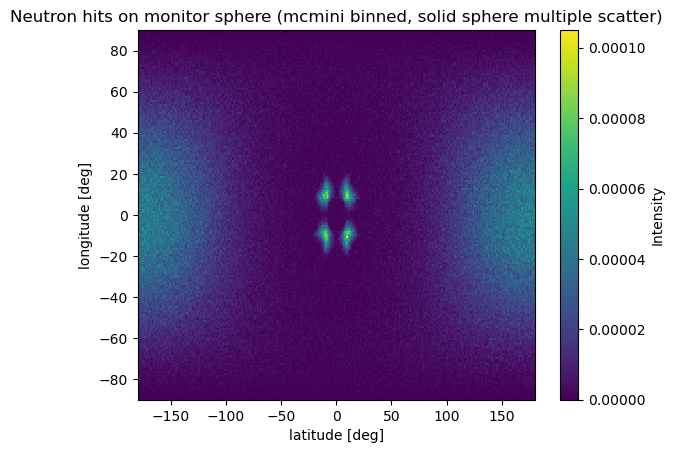

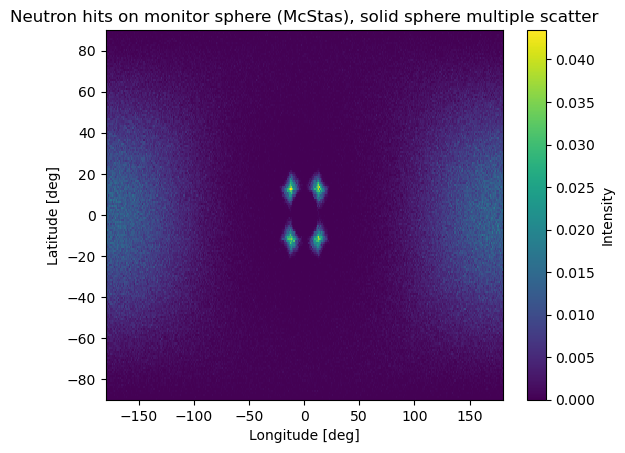

In [27]:
# data from sphere monitor (binned) and soruce simple
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/solid_sphere_multiple_scatter.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
# extract binned data

nx, ny = 360, 180
binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
col_counts = binned_data[:,2]
H = col_counts.reshape((ny, nx)) # normalize to total counts
# H = col_counts.reshape((ny, nx)) * 167.632 # for 0.4m focus
extent = [-180, 180, -90, 90]
plt.imshow(H, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel("latitude [deg]")
plt.ylabel("longitude [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (mcmini binned, solid sphere multiple scatter)")
plt.show()


# plot from mcstas
# plot the data from mcstas
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_sphere_validation/solid_sphere")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = hits
if Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
plt.imshow(Hmc, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
plt.ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (McStas), solid sphere multiple scatter")
plt.show()

### now for the cylinder multiple scattering

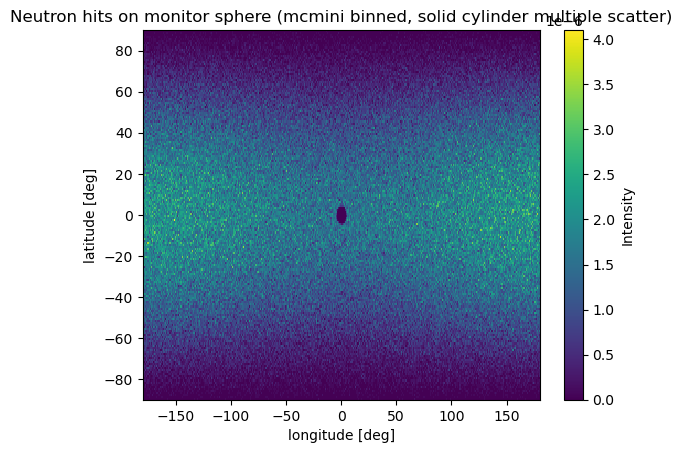

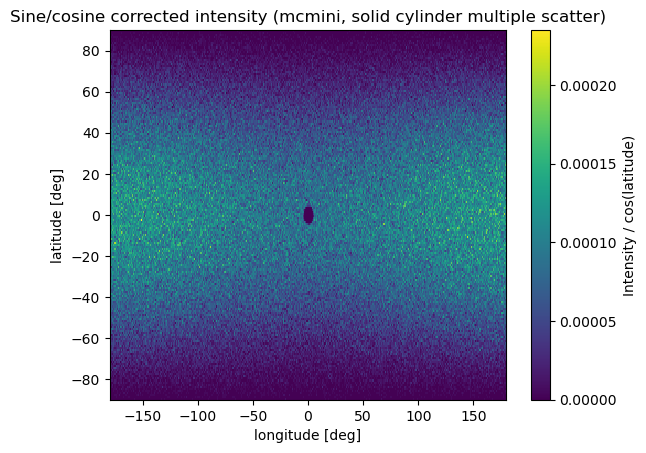

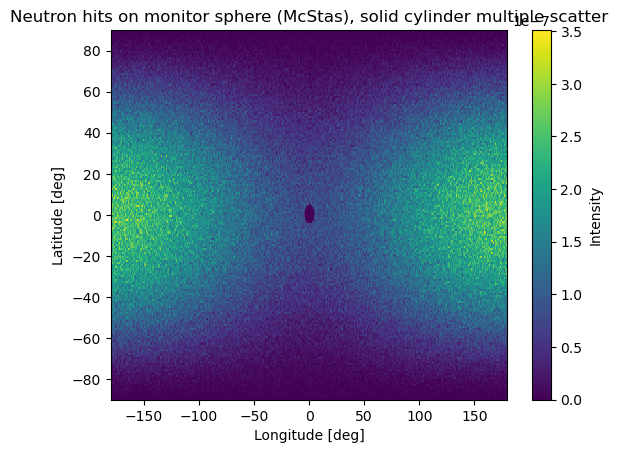

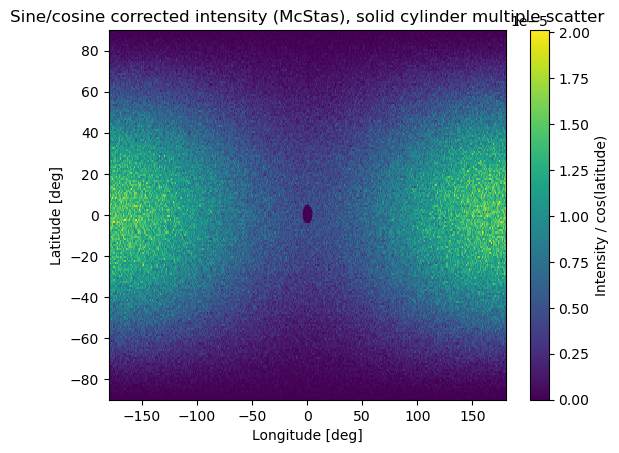

In [66]:
# data from sphere monitor (binned) and source simple
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini/solid_cylinder_multiple_scatter.csv")
if not mcmini_binned_path.is_file():
    raise FileNotFoundError(f"Expected hit file at {mcmini_binned_path}")
# extract binned data

nx, ny = 360, 180
binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
col_counts = binned_data[:, 2]
H = col_counts.reshape((ny, nx))  # (latitude bins, longitude bins)

extent = [-180, 180, -90, 90]

# sine dependence correction (build a 2D weight map that broadcasts to H)
latitude = np.arange(-89,89,180)
cos_angle = np.cos(np.radians(latitude))
# create 180,360 array of sine values that varies only with latitude
cos_correction = cos_angle[:, np.newaxis]  # shape (180, 1), will broadcast to (180, 360)
H_corr = H / np.where(cos_correction == 0, np.nan, cos_correction)  # apply correction, avoid divide by zero


plt.figure()
plt.imshow(H, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (mcmini binned, solid cylinder multiple scatter)")
plt.show()

plt.figure()
plt.imshow(H_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.colorbar(label="Intensity / cos(latitude)")
plt.title("Sine/cosine corrected intensity (mcmini, solid cylinder multiple scatter)")
plt.show()


# plot from mcstas
sphere_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/cylinder_validation/solid_cylinder")[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = hits
if Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
plt.imshow(Hmc, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
plt.ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
plt.colorbar(label="Intensity")
plt.title("Neutron hits on monitor sphere (McStas), solid cylinder multiple scatter")
plt.show()

Hmc_corr = Hmc / np.where(cos_correction == 0, np.nan, cos_correction)  # apply same sine correction to McStas data
plt.figure()
plt.imshow(Hmc_corr, origin="lower", extent=extent, interpolation="nearest", aspect="auto")
plt.xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
plt.ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
plt.colorbar(label="Intensity / cos(latitude)")
plt.title("Sine/cosine corrected intensity (McStas), solid cylinder multiple scatter")
plt.show()